# Home Credit Default Risk
### Submitted by: Omar Mohamed, 12th of October 2024
## Problem definition
The objective is to use historical loan application data to predict whether or not an applicant can repay a loan on time. This is a standard supervised classification task:

## Dataset

There are 7 different sources of data:

application_train/application_test: the main training and testing data with information about each loan application at Home Credit. Every loan has its own row and is identified by the feature SK_ID_CURR. The training application data comes with the TARGET indicating 0: the loan was repaid or 1: the loan was not repaid.
bureau: data concerning client's previous credits from other financial institutions. Each previous credit has its own row in bureau, but one loan in the application data can have multiple previous credits.
bureau_balance: monthly data about the previous credits in bureau. Each row is one month of a previous credit, and a single previous credit can have multiple rows, one for each month of the credit length.
previous_application: previous applications for loans at Home Credit of clients who have loans in the application data. Each current loan in the application data can have multiple previous loans. Each previous application has one row and is identified by the feature SK_ID_PREV.
POS_CASH_BALANCE: monthly data about previous point of sale or cash loans clients have had with Home Credit. Each row is one month of a previous point of sale or cash loan, and a single previous loan can have many rows.
credit_card_balance: monthly data about previous credit cards clients have had with Home Credit. Each row is one month of a credit card balance, and a single credit card can have many rows.
installments_payment: payment history for previous loans at Home Credit. There is one row for every made payment and one row for every missed payment.

In [1]:
import numpy as np
import pandas as pd 
pd.set_option('display.float_format', lambda x: '%.5f' % x)

import warnings
from sklearn.preprocessing import OneHotEncoder
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

def one_hot_encoded_df(df):
    encoder = OneHotEncoder(handle_unknown='ignore',sparse_output=False,drop='first')
    categorical_columns = df.select_dtypes(include=['object']).columns.tolist()
    one_hot_encoded = encoder.fit_transform(df[categorical_columns])
    one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(categorical_columns))
    df_encoded = pd.concat([df, one_hot_df], axis=1)
    df_encoded = df_encoded.drop(categorical_columns, axis=1)
    return df_encoded

### Read Dataset

In [2]:
application_train = pd.read_csv("Data/application_train.csv")
application_test = pd.read_csv("Data/application_test.csv")
bureau = pd.read_csv("Data/bureau.csv")
bureau_balance = pd.read_csv("Data/bureau_balance.csv")
previous_application = pd.read_csv("Data/previous_application.csv")
POS_CHASH_BALANCE = pd.read_csv("Data/POS_CASH_balance.csv")
installments_payments = pd.read_csv("Data/installments_payments.csv")
credit_card_balance = pd.read_csv("Data/credit_card_balance.csv")

## Exploratory Data Analysis
### Application table

In [3]:
print(application_train.shape)
print(application_test.shape)
print(application_train.info())
application_train.head()

(307511, 122)
(48744, 121)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB
None


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.00000,406597.50000,24700.50000,...,0,0,0,0,0.00000,0.00000,0.00000,0.00000,0.00000,1.00000
1,100003,0,Cash loans,F,N,N,0,270000.00000,1293502.50000,35698.50000,...,0,0,0,0,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
2,100004,0,Revolving loans,M,Y,Y,0,67500.00000,135000.00000,6750.00000,...,0,0,0,0,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
3,100006,0,Cash loans,F,N,Y,0,135000.00000,312682.50000,29686.50000,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.00000,513000.00000,21865.50000,...,0,0,0,0,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000


### Distribution of the Target Column

TARGET
0    282686
1     24825
Name: count, dtype: int64


[Text(0, 0, 'Repaid on time'), Text(1, 0, 'Payment difficulties')]

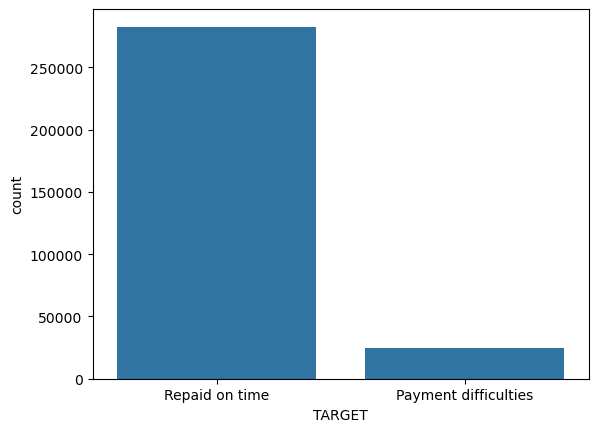

In [4]:
print(application_train['TARGET'].value_counts())
ax = sns.countplot(x ='TARGET', data = application_train)
ax.set_xticklabels(['Repaid on time', 'Payment difficulties'])

There is an imbalanced class problem, which will be overcome using class weighting.

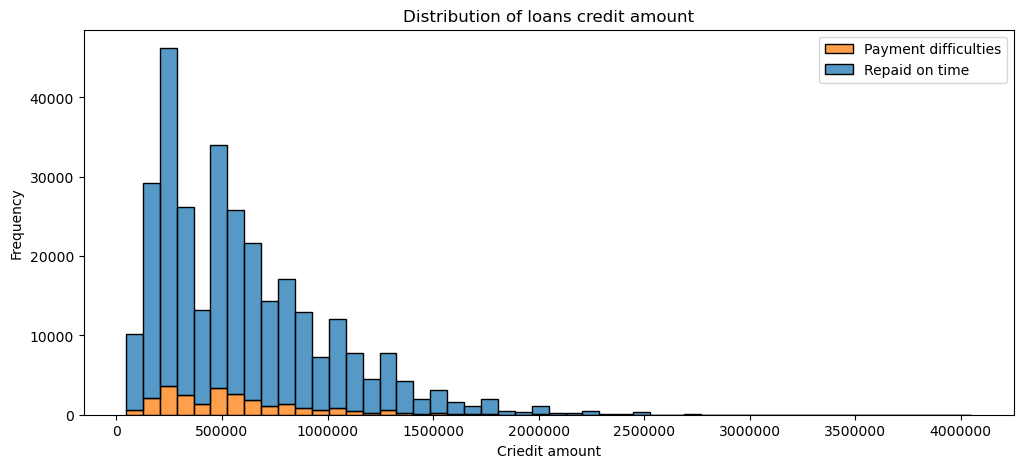

count    307511.00000
mean     599025.99971
std      402490.77700
min       45000.00000
25%      270000.00000
50%      513531.00000
75%      808650.00000
max     4050000.00000
Name: AMT_CREDIT, dtype: float64


In [5]:
plt.figure(figsize=(12, 5))
sns.histplot(data=application_train, x='AMT_CREDIT', bins=50, hue='TARGET', multiple='stack')
plt.title('Distribution of loans credit amount')
plt.xlabel('Criedit amount')
plt.ylabel('Frequency')
plt.ticklabel_format(style = 'plain', axis = 'x')
plt.legend(labels=['Payment difficulties','Repaid on time'])
plt.show()
print(application_train['AMT_CREDIT'].describe())

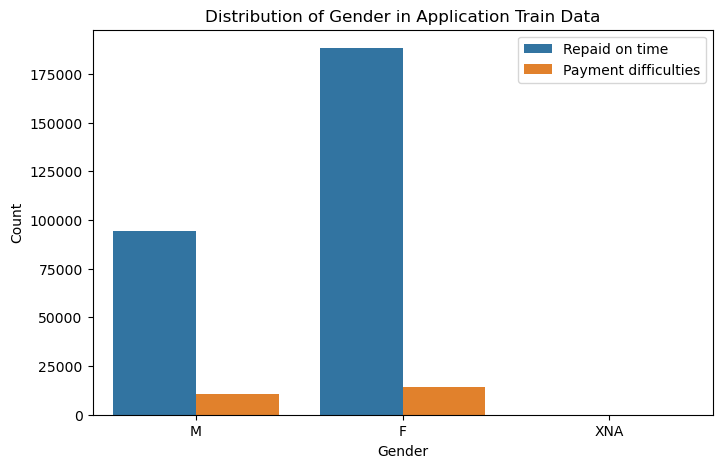

In [6]:
plt.figure(figsize=(8, 5))
sns.countplot(x='CODE_GENDER', data=application_train, hue='TARGET')
plt.title('Distribution of Gender in Application Train Data')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(labels=['Repaid on time', 'Payment difficulties'])
plt.show()

In [7]:
application_train['DAYS_BIRTH'] = abs(application_train['DAYS_BIRTH'])
application_train['DAYS_EMPLOYED'] = abs(application_train['DAYS_BIRTH'])
application_train['DAYS_ID_PUBLISH'] = abs(application_train['DAYS_ID_PUBLISH'])

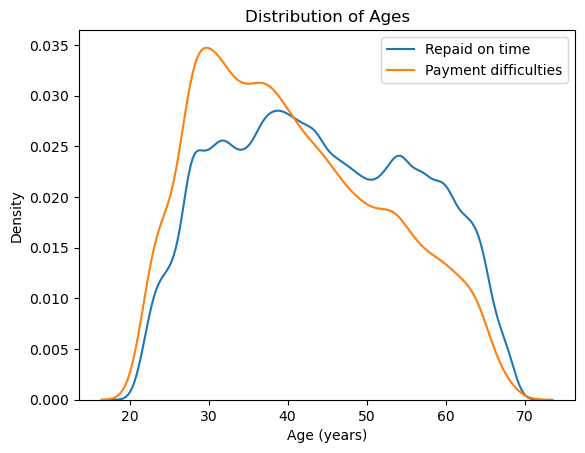

In [8]:
sns.kdeplot(application_train.loc[application_train['TARGET'] == 0, 'DAYS_BIRTH'] / 365, label = 'Repaid on time')

sns.kdeplot(application_train.loc[application_train['TARGET'] == 1, 'DAYS_BIRTH'] / 365, label = 'Payment difficulties')
plt.legend()
plt.xlabel('Age (years)'); plt.ylabel('Density'); plt.title('Distribution of Ages');

There is a clear trend: younger applicants are more likely to not repay the loan! The rate of failure to repay is above 10% for the youngest three age groups and beolow 5% for the oldest age group.

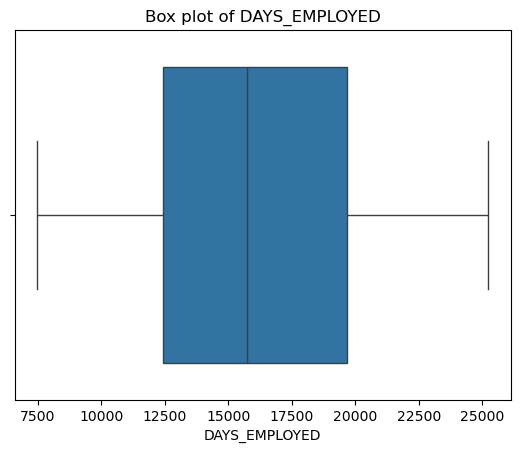

In [9]:
sns.boxplot(x=application_train['DAYS_EMPLOYED'])
plt.title('Box plot of DAYS_EMPLOYED')
plt.xlabel('DAYS_EMPLOYED')
plt.show()

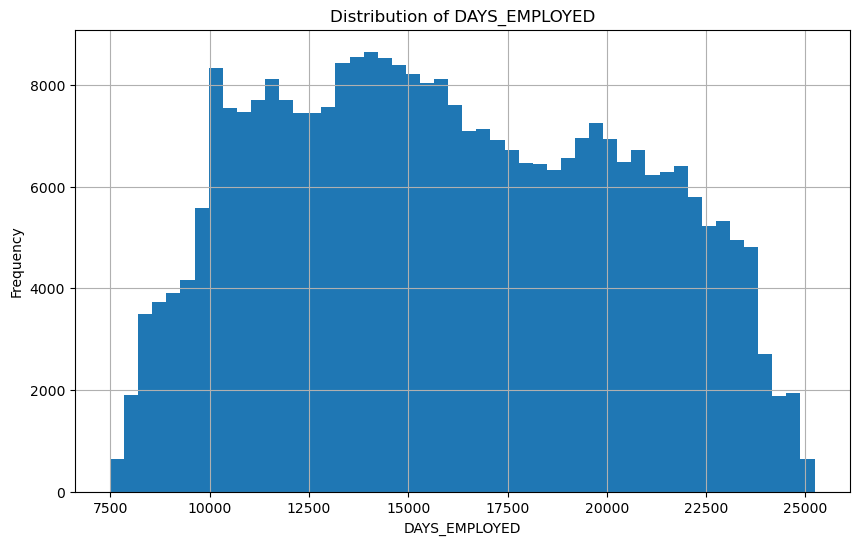

In [10]:
plt.figure(figsize=(10, 6))
application_train['DAYS_EMPLOYED'].hist(bins=50)
plt.title('Distribution of DAYS_EMPLOYED')
plt.xlabel('DAYS_EMPLOYED')
plt.ylabel('Frequency')
plt.show()

### Application Table Feature Engineering  

In [11]:
application_train['CREDIT_LENGTH'] = application_train['AMT_CREDIT'] / application_train['AMT_ANNUITY']
application_train['CREDIT_INCOME_PERCENT'] = application_train['AMT_CREDIT'] / application_train['AMT_INCOME_TOTAL']
application_train['ANNUITY_INCOME_PERCENT'] = application_train['AMT_ANNUITY'] / application_train['AMT_INCOME_TOTAL']
application_train['DAYS_EMPLOYED_PERCENT'] = application_train['DAYS_EMPLOYED'] / application_train['DAYS_BIRTH']
application_train['AGE_int'] = application_train['DAYS_BIRTH'].apply(lambda x: int(x / 365))
application_train['DAYS_EMPLOYED_CREDIT_LENGTH_PERCENT'] = application_train['DAYS_EMPLOYED'] / application_train['CREDIT_LENGTH']
application_train['income_per_person'] = application_train['AMT_INCOME_TOTAL'] / application_train['CNT_FAM_MEMBERS']
application_train['AMT_ANNUITY_income_per_person_ratio'] = application_train['AMT_ANNUITY']/application_train['income_per_person']
application_train['AMT_ANNUITY_AMT_INCOME_TOTAL_RATIO']= application_train['AMT_ANNUITY']/application_train['AMT_INCOME_TOTAL']

application_test['CREDIT_LENGTH'] = application_test['AMT_CREDIT'] / application_test['AMT_ANNUITY']    
application_test['CREDIT_INCOME_PERCENT'] = application_test['AMT_CREDIT'] / application_test['AMT_INCOME_TOTAL']
application_test['ANNUITY_INCOME_PERCENT'] = application_test['AMT_ANNUITY'] / application_test['AMT_INCOME_TOTAL']
application_test['DAYS_EMPLOYED_PERCENT'] = application_test['DAYS_EMPLOYED'] / application_test['DAYS_BIRTH']
application_test['AGE_int'] = application_test['DAYS_BIRTH'].apply(lambda x: int(x / 365))
application_test['income_per_person'] = application_test['AMT_INCOME_TOTAL'] / application_test['CNT_FAM_MEMBERS']
application_test['AMT_ANNUITY_income_per_person_ratio'] = application_test['AMT_ANNUITY']/application_test['income_per_person'] 
application_test['AMT_ANNUITY_AMT_INCOME_TOTAL_RATIO']= application_test['AMT_ANNUITY']/application_test['AMT_INCOME_TOTAL']

### Application Table Polynomial Features

In [12]:
from sklearn.preprocessing import PolynomialFeatures
poly_features_train = application_train[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH']]
poly_features_test = application_test[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH']]
poly_transformer = PolynomialFeatures(degree = 3)
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy = 'median')
poly_features_train = imputer.fit_transform(poly_features_train)
poly_features_test = imputer.transform(poly_features_test)

poly_transformer.fit(poly_features_train)
poly_features_train = poly_transformer.transform(poly_features_train)
poly_features_test = poly_transformer.transform(poly_features_test)

poly_features_train_df = pd.DataFrame(poly_features_train, columns=poly_transformer.get_feature_names_out(input_features=['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH']))
poly_features_train_df = poly_features_train_df.iloc[:, 5:]
poly_features_train_df.head()

poly_features_test_df = pd.DataFrame(poly_features_test, columns=poly_transformer.get_feature_names_out(input_features=['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH'])) 
poly_features_test_df = poly_features_test_df.iloc[:, 5:]
poly_features_test_df.head()

application_train = pd.concat([application_train, poly_features_train_df], axis=1)
application_test = pd.concat([application_test, poly_features_test_df], axis=1)

In [13]:
application_train

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,EXT_SOURCE_2^3,EXT_SOURCE_2^2 EXT_SOURCE_3,EXT_SOURCE_2^2 DAYS_BIRTH,EXT_SOURCE_2 EXT_SOURCE_3^2,EXT_SOURCE_2 EXT_SOURCE_3 DAYS_BIRTH,EXT_SOURCE_2 DAYS_BIRTH^2,EXT_SOURCE_3^3,EXT_SOURCE_3^2 DAYS_BIRTH,EXT_SOURCE_3 DAYS_BIRTH^2,DAYS_BIRTH^3
0,100002,1,Cash loans,M,N,Y,0,202500.00000,406597.50000,24700.50000,...,0.01818,0.00964,654.15211,0.00511,346.73302,23536665.53302,0.00271,183.78568,12475598.69151,846859039181.00000
1,100003,0,Cash loans,F,N,N,0,270000.00000,1293502.50000,35698.50000,...,0.24093,0.20725,6491.23708,0.17829,5583.97531,174891648.82749,0.15337,4803.51894,150447539.77620,4712058497125.00000
2,100004,0,Revolving loans,M,Y,Y,0,67500.00000,135000.00000,6750.00000,...,0.17180,0.22546,5885.94240,0.29589,7724.58029,201657172.73568,0.38832,10137.56788,264650401.68334,6908938709336.00000
3,100006,0,Cash loans,F,N,Y,0,135000.00000,312682.50000,29686.50000,...,0.27519,0.22646,8040.52883,0.18636,6616.89462,234933050.41715,0.15337,5445.32523,193336442.29006,6864416425125.00000
4,100007,0,Cash loans,M,N,Y,0,121500.00000,513000.00000,21865.50000,...,0.03362,0.05575,2076.11716,0.09247,3443.33552,128218958.98944,0.15337,5710.92988,212657023.90509,7918677125568.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251,0,Cash loans,M,N,N,0,157500.00000,254700.00000,27558.00000,...,0.31670,0.24870,4333.53580,0.19530,3403.06432,59297196.33033,0.15337,2672.37824,46565248.85274,811383048783.00000
307507,456252,0,Cash loans,F,N,Y,0,72000.00000,269550.00000,12001.50000,...,0.00156,0.00720,279.51019,0.03323,1289.87408,50062251.12275,0.15337,5952.46680,231025564.25158,8966502984375.00000
307508,456253,0,Cash loans,F,N,Y,0,153000.00000,677664.00000,29979.00000,...,0.15375,0.06281,4295.20900,0.02566,1754.72715,119991577.24137,0.01048,716.86089,49020310.23861,3352101980696.00000
307509,456254,1,Cash loans,F,N,Y,0,171000.00000,370107.00000,20205.00000,...,0.13593,0.17475,3162.05070,0.22466,4065.22965,73558971.77728,0.28884,5226.38430,94569677.01901,1711206696681.00000


### Bureau Table 

In [14]:
bureau.info()
print(bureau.shape)
bureau.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1716428 entries, 0 to 1716427
Data columns (total 17 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   SK_ID_CURR              int64  
 1   SK_ID_BUREAU            int64  
 2   CREDIT_ACTIVE           object 
 3   CREDIT_CURRENCY         object 
 4   DAYS_CREDIT             int64  
 5   CREDIT_DAY_OVERDUE      int64  
 6   DAYS_CREDIT_ENDDATE     float64
 7   DAYS_ENDDATE_FACT       float64
 8   AMT_CREDIT_MAX_OVERDUE  float64
 9   CNT_CREDIT_PROLONG      int64  
 10  AMT_CREDIT_SUM          float64
 11  AMT_CREDIT_SUM_DEBT     float64
 12  AMT_CREDIT_SUM_LIMIT    float64
 13  AMT_CREDIT_SUM_OVERDUE  float64
 14  CREDIT_TYPE             object 
 15  DAYS_CREDIT_UPDATE      int64  
 16  AMT_ANNUITY             float64
dtypes: float64(8), int64(6), object(3)
memory usage: 222.6+ MB
(1716428, 17)


,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.00000,-153.00000,NaN,0,91323.00000,0.00000,NaN,0.00000,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.00000,NaN,NaN,0,225000.00000,171342.00000,NaN,0.00000,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.00000,NaN,NaN,0,464323.50000,NaN,NaN,0.00000,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.00000,NaN,NaN,0.00000,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.00000,NaN,77674.50000,0,2700000.00000,NaN,NaN,0.00000,Consumer credit,-21,NaN


In [15]:
bureau_balance.info()
bureau_balance.head()
print(bureau_balance.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27299925 entries, 0 to 27299924
Data columns (total 3 columns):
 #   Column          Dtype 
---  ------          ----- 
 0   SK_ID_BUREAU    int64 
 1   MONTHS_BALANCE  int64 
 2   STATUS          object
dtypes: int64(2), object(1)
memory usage: 624.8+ MB
(27299925, 3)


### BUREAU & BUREAU_balance Feature Engineering

In [16]:
bureau.head()

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.00000,-153.00000,NaN,0,91323.00000,0.00000,NaN,0.00000,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.00000,NaN,NaN,0,225000.00000,171342.00000,NaN,0.00000,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.00000,NaN,NaN,0,464323.50000,NaN,NaN,0.00000,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.00000,NaN,NaN,0.00000,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.00000,NaN,77674.50000,0,2700000.00000,NaN,NaN,0.00000,Consumer credit,-21,NaN


In [17]:
bureau_balance.head()

,SK_ID_BUREAU,MONTHS_BALANCE,STATUS
0,5715448,0,C
1,5715448,-1,C
2,5715448,-2,C
3,5715448,-3,C
4,5715448,-4,C


### Bureau & Bureau balance Tbls Feature Engineering

In [18]:
recent_days_credit = bureau[bureau['CREDIT_ACTIVE'] == 'Active'].groupby('SK_ID_CURR')['DAYS_CREDIT'].max().reset_index()
recent_days_credit.columns = ['SK_ID_CURR', 'RECENT_DAYS_LAST_ACTIVE_CREDIT']
application_train = application_train.merge(recent_days_credit, on='SK_ID_CURR', how='left')
application_test = application_test.merge(recent_days_credit, on='SK_ID_CURR', how='left')

CREDIT_DEBT_RATIO = bureau.groupby('SK_ID_CURR').agg({'AMT_CREDIT_SUM_DEBT': 'sum', 'AMT_CREDIT_SUM': 'sum'}).reset_index()
CREDIT_DEBT_RATIO['CREDIT_DEBT_RATIO'] = CREDIT_DEBT_RATIO['AMT_CREDIT_SUM_DEBT'] / CREDIT_DEBT_RATIO['AMT_CREDIT_SUM']
CREDIT_DEBT_RATIO = CREDIT_DEBT_RATIO[['SK_ID_CURR', 'CREDIT_DEBT_RATIO']]
application_train = application_train.merge(CREDIT_DEBT_RATIO, on='SK_ID_CURR', how='left')
application_test = application_test.merge(CREDIT_DEBT_RATIO, on='SK_ID_CURR', how='left')

In [19]:
bureau = one_hot_encoded_df(bureau)
bureau_balance = one_hot_encoded_df(bureau_balance)

bureau_bureau_balance = bureau.merge(bureau_balance, how='left', on='SK_ID_BUREAU').mean()

bureau_bureau_balance_mean = bureau.groupby('SK_ID_CURR', as_index=True).mean().reset_index()
bureau_bureau_balance_mean.columns = ['SK_ID_CURR'] + [col + '_bureau_mean' for col in bureau_bureau_balance_mean.columns if col != 'SK_ID_CURR']

bureau_bureau_balance_count = bureau.groupby('SK_ID_CURR', as_index=True).count().reset_index()
bureau_bureau_balance_count.columns = ['SK_ID_CURR'] + [col + '_bureau_count' for col in bureau_bureau_balance_count.columns if col != 'SK_ID_CURR']

### Previous Application & POS_CHASH_BALANCE & installments_payments & credit_card_balance Tbls 

In [20]:
print(previous_application.shape)
print(POS_CHASH_BALANCE.shape)
print(installments_payments.shape)
print(credit_card_balance.shape)

(1670214, 37)
(10001358, 8)
(13605401, 8)
(3840312, 23)


In [21]:
filtered_installments = installments_payments[installments_payments['DAYS_INSTALMENT'] > -1000]
INSTALLMENT_DIFF_MEAN = filtered_installments.groupby(['SK_ID_PREV']).apply(lambda x: (x['AMT_PAYMENT'] - x['AMT_INSTALMENT']).mean()).reset_index(name='INSTALLMENT_DIFF_MEAN')
previous_application = previous_application.merge(INSTALLMENT_DIFF_MEAN, how='left', on='SK_ID_PREV')

max_installment = installments_payments.groupby('SK_ID_CURR')['AMT_INSTALMENT'].max().reset_index()
max_installment.columns = ['SK_ID_CURR', 'MAX_AMT_INSTALMENT']
application_test = application_test.merge(max_installment, on='SK_ID_CURR', how='left')
application_test['annuity_to_max_installment_ratio'] = application_test['AMT_ANNUITY'] / application_test['MAX_AMT_INSTALMENT']
application_train = application_train.merge(max_installment, on='SK_ID_CURR', how='left')
application_train['annuity_to_max_installment_ratio'] = application_train['AMT_ANNUITY'] / application_train['MAX_AMT_INSTALMENT']

POS_CHASH_BALANCE = one_hot_encoded_df(POS_CHASH_BALANCE)
POS_CHASH_BALANCE_mean = POS_CHASH_BALANCE.groupby('SK_ID_PREV', as_index=True).mean().reset_index()
POS_CHASH_BALANCE_mean.columns = ['SK_ID_PREV'] + [col + '_POS_CASH_BALANCE_mean' for col in POS_CHASH_BALANCE_mean.columns if col != 'SK_ID_PREV']

POS_CHASH_BALANCE_count = POS_CHASH_BALANCE.groupby('SK_ID_PREV', as_index=True).count().reset_index()
POS_CHASH_BALANCE_count.columns = ['SK_ID_PREV'] + [col + '_POS_CASH_BALANCE_count' for col in POS_CHASH_BALANCE_count.columns if col != 'SK_ID_PREV']
installments_payments = one_hot_encoded_df(installments_payments)
installments_payments_mean = installments_payments.groupby('SK_ID_PREV', as_index=True).mean().reset_index()
installments_payments_mean.columns = ['SK_ID_PREV'] + [col + '_installments_payments_mean' for col in installments_payments_mean.columns if col != 'SK_ID_PREV']

installments_payments_count = installments_payments.groupby('SK_ID_PREV', as_index=True).count().reset_index()
installments_payments_count.columns = ['SK_ID_PREV'] + [col + '_installments_payments_count' for col in installments_payments_count.columns if col != 'SK_ID_PREV']

credit_card_balance = one_hot_encoded_df(credit_card_balance)
credit_card_balance_mean = credit_card_balance.groupby('SK_ID_PREV', as_index=True).mean().reset_index()
credit_card_balance_mean.columns = ['SK_ID_PREV'] + [col + '_credit_card_balance_mean' for col in credit_card_balance_mean.columns if col != 'SK_ID_PREV']

credit_card_balance_count = credit_card_balance.groupby('SK_ID_PREV', as_index=True).count().reset_index()
credit_card_balance_count.columns = ['SK_ID_PREV'] + [col + '_credit_card_balance_count' for col in credit_card_balance_count.columns if col != 'SK_ID_PREV']

previous_application = previous_application.merge(POS_CHASH_BALANCE_mean, how='left', on='SK_ID_PREV')
previous_application = previous_application.merge(POS_CHASH_BALANCE_count, how='left', on='SK_ID_PREV')
previous_application = previous_application.merge(installments_payments_mean, how='left', on='SK_ID_PREV')
previous_application = previous_application.merge(installments_payments_count, how='left', on='SK_ID_PREV')
previous_application = previous_application.merge(credit_card_balance_mean, how='left', on='SK_ID_PREV')
previous_application = previous_application.merge(credit_card_balance_count, how='left', on='SK_ID_PREV')

In [22]:
#previous_application = pd.read_csv("Data/previous_application.csv")
# Filter the previous_application dataframe for rows where NAME_CONTRACT_STATUS is 'Canceled'
canceled_applications = previous_application[previous_application['NAME_CONTRACT_STATUS'] == 'Canceled']

# Group by SK_ID_CURR and count the number of canceled applications
canceled_counts = canceled_applications.groupby('SK_ID_CURR').size().reset_index(name='canceled_count')

# Display the first few rows of the result
#canceled_counts.head()

# Filter the previous_application dataframe for rows where NAME_CONTRACT_STATUS is 'Canceled'
Approved_applications = previous_application[previous_application['NAME_CONTRACT_STATUS'] == 'Approved']

# Group by SK_ID_CURR and count the number of canceled applications
Approved_counts = canceled_applications.groupby('SK_ID_CURR').size().reset_index(name='Approved_count')

# Display the first few rows of the result
#Approved_counts.sort_values(by='Approved_count', ascending=False).head()

CONTRACT_STATUS_insights = Approved_counts.merge(canceled_counts, on='SK_ID_CURR', how='left')
CONTRACT_STATUS_insights['CONTRACT_STATUS_APPROVED_Canceled_RATIO'] = CONTRACT_STATUS_insights['Approved_count'] / CONTRACT_STATUS_insights['canceled_count']

application_train = application_train.merge(CONTRACT_STATUS_insights, on='SK_ID_CURR', how='left')
application_test = application_test.merge(CONTRACT_STATUS_insights, on='SK_ID_CURR', how='left')

In [23]:
previous_application['NAME_CLIENT_TYPE'].value_counts()

NAME_CLIENT_TYPE
Repeater     1231261
New           301363
Refreshed     135649
XNA             1941
Name: count, dtype: int64

In [24]:
previous_application['RATE_INTEREST_PRIVILEGED_PRIMARY_ratio'] =  previous_application['RATE_INTEREST_PRIVILEGED']/previous_application['RATE_INTEREST_PRIMARY']
previous_application['credit_annuity_ratio'] = previous_application['AMT_CREDIT']/previous_application['AMT_ANNUITY']
previous_application['credit_downpayment'] = previous_application['AMT_GOODS_PRICE'] - previous_application['AMT_CREDIT']


previous_application['Laon_credit_ASK_ratio'] = previous_application.apply(
    lambda row: row['AMT_CREDIT'] / row['AMT_APPLICATION'] if row['AMT_APPLICATION'] != 0 and not pd.isnull(row['AMT_APPLICATION']) else np.nan,
    axis=1)

previous_application['DOWN_PAYMENT_GOODS_RATIO'] = previous_application.apply(
    lambda row: row['AMT_DOWN_PAYMENT'] / row['AMT_GOODS_PRICE'] if row['AMT_GOODS_PRICE'] != 0 and not pd.isnull(row['AMT_GOODS_PRICE']) else np.nan,
    axis=1)

previous_application['AMT_CREDIT_GOODS_RATIO'] = previous_application.apply(lambda row: row['AMT_CREDIT'] / row['AMT_GOODS_PRICE'] if row['AMT_GOODS_PRICE'] != 0 and not pd.isnull(row['AMT_GOODS_PRICE']) else np.nan,
    axis=1)



previous_application = one_hot_encoded_df(previous_application)
previous_application_mean = previous_application.groupby('SK_ID_CURR', as_index=False).mean()
previous_application_mean.columns = ['SK_ID_CURR'] + [col + '_previous_application_mean' for col in previous_application_mean.columns if col != 'SK_ID_CURR']

previous_application_count = previous_application.groupby('SK_ID_CURR', as_index=False).count()
previous_application_count.columns = ['SK_ID_CURR'] + [col + '_previous_application_count' for col in previous_application_count.columns if col != 'SK_ID_CURR']


### Merge With Application Tbl

In [25]:
application_train = application_train.merge(bureau_bureau_balance_mean, on = 'SK_ID_CURR', how = 'left')
application_train = application_train.merge(bureau_bureau_balance_count, on = 'SK_ID_CURR', how = 'left')
application_train = application_train.merge(previous_application_mean, on = 'SK_ID_CURR', how = 'left')
application_train = application_train.merge(previous_application_count, on = 'SK_ID_CURR', how = 'left')

application_test = application_test.merge(bureau_bureau_balance_mean, on = 'SK_ID_CURR', how = 'left')
application_test = application_test.merge(bureau_bureau_balance_count, on = 'SK_ID_CURR', how = 'left')
application_test = application_test.merge(previous_application_mean, on = 'SK_ID_CURR', how = 'left')
application_test = application_test.merge(previous_application_count, on = 'SK_ID_CURR', how = 'left')

### Missing Values

In [26]:
def missing_values_table(df):
        # Total missing values
        mis_val = df.isnull().sum()
        
        # Percentage of missing values
        mis_val_percent = 100 * df.isnull().sum() / len(df)
        
        # Make a table with the results
        mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)
        
        # Rename the columns
        mis_val_table_ren_columns = mis_val_table.rename(
        columns = {0 : 'Missing Values', 1 : '% of Total Values'})
        
        # Sort the table by percentage of missing descending
        mis_val_table_ren_columns = mis_val_table_ren_columns[
            mis_val_table_ren_columns.iloc[:,1] != 0].sort_values(
        '% of Total Values', ascending=False).round(1)
        
        # Print some summary information
        print ("Your selected dataframe has " + str(df.shape[1]) + " columns.\n"      
            "There are " + str(mis_val_table_ren_columns.shape[0]) +
              " columns that have missing values.")
        
        # Return the dataframe with missing information
        return mis_val_table_ren_columns

missing_values = missing_values_table(application_train)
missing_values.head(20)

Your selected dataframe has 738 columns.
There are 650 columns that have missing values.


,Missing Values,% of Total Values
RATE_INTEREST_PRIMARY_previous_application_mean,302902,98.50000
RATE_INTEREST_PRIVILEGED_previous_application_mean,302902,98.50000
RATE_INTEREST_PRIVILEGED_PRIMARY_ratio_previous_application_mean,302902,98.50000
AMT_PAYMENT_CURRENT_credit_card_balance_mean_previous_application_mean,254669,82.80000
CNT_DRAWINGS_ATM_CURRENT_credit_card_balance_mean_previous_application_mean,254581,82.80000
AMT_DRAWINGS_ATM_CURRENT_credit_card_balance_mean_previous_application_mean,254581,82.80000
CNT_DRAWINGS_POS_CURRENT_credit_card_balance_mean_previous_application_mean,254581,82.80000
CNT_DRAWINGS_OTHER_CURRENT_credit_card_balance_mean_previous_application_mean,254581,82.80000
AMT_DRAWINGS_POS_CURRENT_credit_card_balance_mean_previous_application_mean,254581,82.80000
AMT_DRAWINGS_OTHER_CURRENT_credit_card_balance_mean_previous_application_mean,254581,82.80000


#### Drop columns with missing percentage > 90%

In [27]:
high_missing_values = missing_values[missing_values['% of Total Values'] > 90]
print(high_missing_values.count())
application_train = application_train.drop(columns=high_missing_values.index)

Missing Values       3
% of Total Values    3
dtype: int64


### One Hot Encoding

In [28]:
# one-hot encoding of categorical variables
from sklearn.preprocessing import OneHotEncoder
#encoder = OneHotEncoder(handle_unknown='ignore',sparse_output=False)
#categorical_columns = application_train.select_dtypes(include=['object']).columns.tolist()
#one_hot_encoded = encoder.fit_transform(df[categorical_columns])
#application_train = pd.get_dummies(application_train)
#application_test = pd.get_dummies(application_test)

def one_hot_encoded_df(df):
    encoder = OneHotEncoder(handle_unknown='ignore',sparse_output=False,drop='first')
    categorical_columns = df.select_dtypes(include=['object']).columns.tolist()
    one_hot_encoded = encoder.fit_transform(df[categorical_columns])
    one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(categorical_columns))
    df_encoded = pd.concat([df, one_hot_df], axis=1)
    df_encoded = df_encoded.drop(categorical_columns, axis=1)
    return df_encoded

#application_train = one_hot_encoded_df(application_train)
#application_test = one_hot_encoded_df(application_test)

train = pd.get_dummies(application_train)
test = pd.get_dummies(application_test)
train_labels = application_train['TARGET']

# Align the training and testing data, keep only columns present in both dataframes
train, test = train.align(test, join = 'inner', axis = 1)
train['TARGET'] = train_labels
# Add the target back in
#application_train['TARGET'] = train_labels


print('Training Features shape: ', train.shape)
print('Testing Features shape: ', test.shape)

Training Features shape:  (307511, 855)
Testing Features shape:  (48744, 854)


### Check for infinity values

In [29]:
# Check for infinity values in the application_train DataFrame
#infinity_values = application_train.isin([np.inf, -np.inf]).sum()
#print("Columns with infinity values:\n", infinity_values[infinity_values > 0])
train.replace([np.inf, -np.inf], np.nan, inplace=True)
test.replace([np.inf, -np.inf], np.nan, inplace=True)

### Find Linear Correlation

In [30]:

correlations = train.corr()['TARGET'].sort_values()
# Display correlations
print('Most Positive Correlations:\n', correlations.tail(30))
print('\nMost Negative Correlations:\n', correlations.head(30))


Most Positive Correlations:
 REG_CITY_NOT_WORK_CITY                                                        0.05099
AMT_DRAWINGS_ATM_CURRENT_credit_card_balance_mean_previous_application_mean   0.05222
DAYS_ENDDATE_FACT_bureau_mean                                                 0.05320
CODE_REJECT_REASON_HC_previous_application_mean                               0.05453
CODE_GENDER_M                                                                 0.05471
DAYS_LAST_PHONE_CHANGE                                                        0.05522
AMT_DRAWINGS_CURRENT_credit_card_balance_mean_previous_application_mean       0.05539
CODE_REJECT_REASON_SCOFR_previous_application_mean                            0.05586
NAME_PRODUCT_TYPE_walk-in_previous_application_mean                           0.05741
NAME_INCOME_TYPE_Working                                                      0.05748
REGION_RATING_CLIENT                                                          0.05890
CREDIT_DEBT_RATIO        

### Features scaling

In [31]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer
y = application_train['TARGET']
features = list(train.columns)
submit = application_test[['SK_ID_CURR']]

train = train.drop(columns = ['TARGET'])
#imputer = SimpleImputer(strategy = 'median')
scaler = MinMaxScaler(feature_range = (0, 1))
'''
imputer.fit(train)
train = imputer.transform(train)
test = imputer.transform(test)  
'''
scaler.fit(train)
train = scaler.transform(train)
test = scaler.transform(test)
print('Training data shape: ', train.shape)
print('Testing data shape: ', test.shape)   

Training data shape:  (307511, 854)
Testing data shape:  (48744, 854)


## Modeling 
### Lightgbm

[LightGBM] [Warning] early_stopping_round is set=200, early_stopping_rounds=200 will be ignored. Current value: early_stopping_round=200
[LightGBM] [Info] Number of positive: 18619, number of negative: 212014
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.089251 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 71263
[LightGBM] [Info] Number of data points in the train set: 230633, number of used features: 845
[LightGBM] [Warning] early_stopping_round is set=200, early_stopping_rounds=200 will be ignored. Current value: early_stopping_round=200
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[429]	test's auc: 0.786477	test's binary_logloss: 0.502663


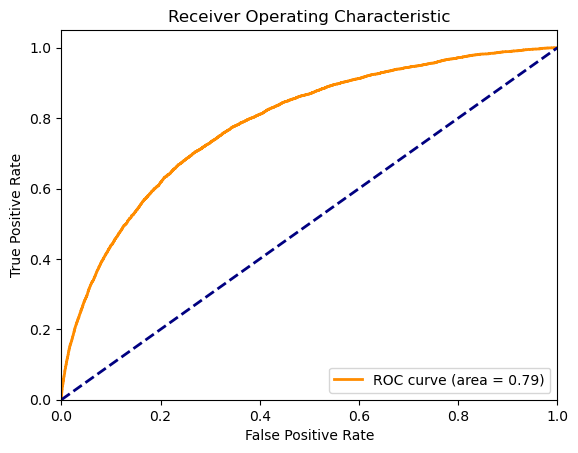

ROC AUC: 0.79


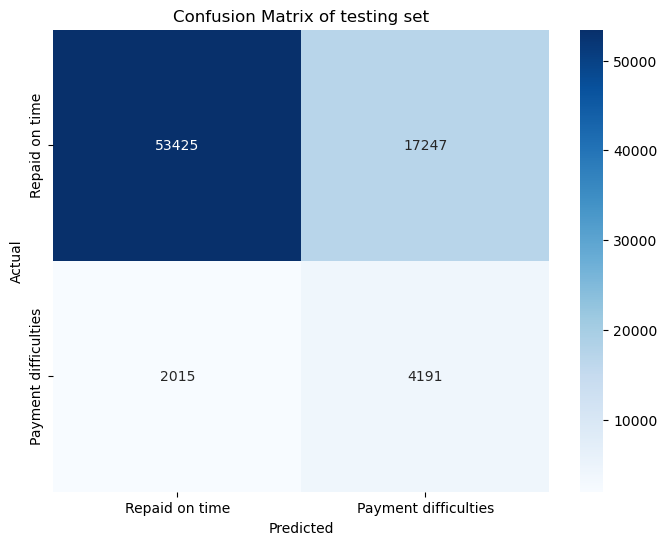

                      precision    recall  f1-score   support

      Repaid on time       0.96      0.76      0.85     70672
Payment difficulties       0.20      0.68      0.30      6206

            accuracy                           0.75     76878
           macro avg       0.58      0.72      0.58     76878
        weighted avg       0.90      0.75      0.80     76878



In [32]:
from sklearn.model_selection import train_test_split
import lightgbm as lgb
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix  # Import the necessary functions

X_train, X_test, y_train, y_test = train_test_split(train, y, test_size=0.25, random_state=42, stratify=y)

model = lgb.LGBMClassifier(n_estimators=10000, objective='binary', 
                           class_weight='balanced', learning_rate=0.05, 
                           reg_alpha=0.1, reg_lambda=0.1, 
                           subsample=0.8, n_jobs=-1, random_state=50,early_stopping_rounds=200)
model.fit(X_train, y_train, eval_metric='auc',eval_set=[(X_test, y_test)],eval_names=['test', 'train'])    

y_pred = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

print(f'ROC AUC: {roc_auc:.2f}')

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred.round())

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Repaid on time', 'Payment difficulties'], yticklabels=['Repaid on time', 'Payment difficulties'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix of testing set')
plt.show()

print(classification_report(y_test, y_pred.round(), target_names=['Repaid on time', 'Payment difficulties']))

### Lightgbm features importance

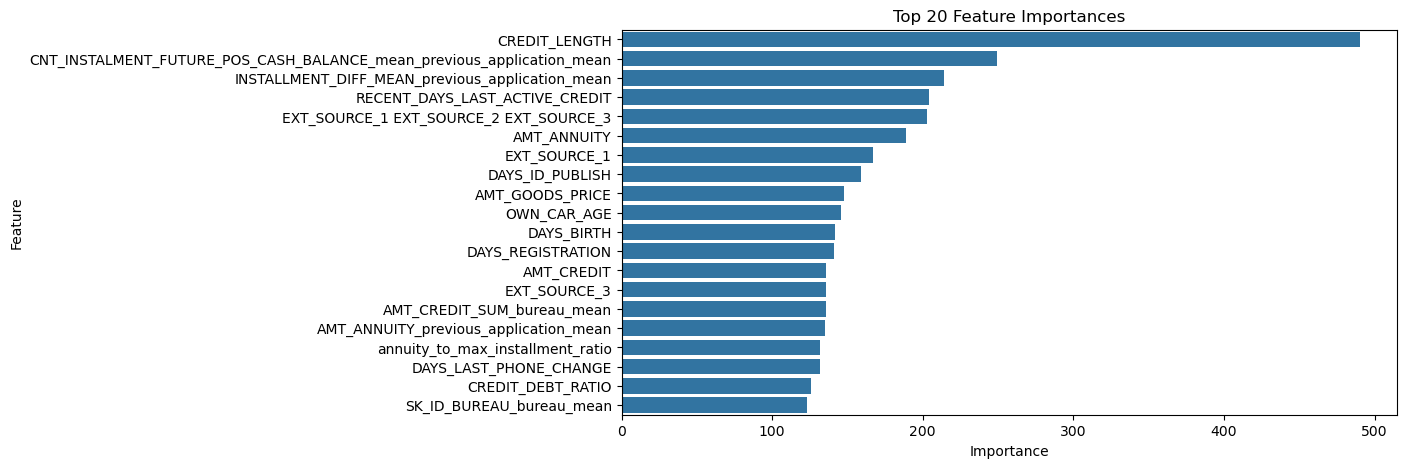

,Feature,Importance
105,CREDIT_LENGTH,490
238,CNT_INSTALMENT_FUTURE_POS_CASH_BALANCE_mean_pr...,249
234,INSTALLMENT_DIFF_MEAN_previous_application_mean,214
143,RECENT_DAYS_LAST_ACTIVE_CREDIT,204
128,EXT_SOURCE_1 EXT_SOURCE_2 EXT_SOURCE_3,203
4,AMT_ANNUITY,189
28,EXT_SOURCE_1,167
10,DAYS_ID_PUBLISH,159
5,AMT_GOODS_PRICE,148
11,OWN_CAR_AGE,146


In [41]:
#features.remove('TARGET')
feature_importances = model.feature_importances_
# Create a DataFrame for better visualization
feature_importances_df = pd.DataFrame({
    'Feature': features,
    'Importance': feature_importances
})

# Sort the DataFrame by importance
feature_importances_df = feature_importances_df.sort_values(by='Importance', ascending=False)

# Plot the feature importances
plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=feature_importances_df.head(20))
plt.title('Top 20 Feature Importances')
plt.show()

# Display the DataFrame
feature_importances_df.head(20)

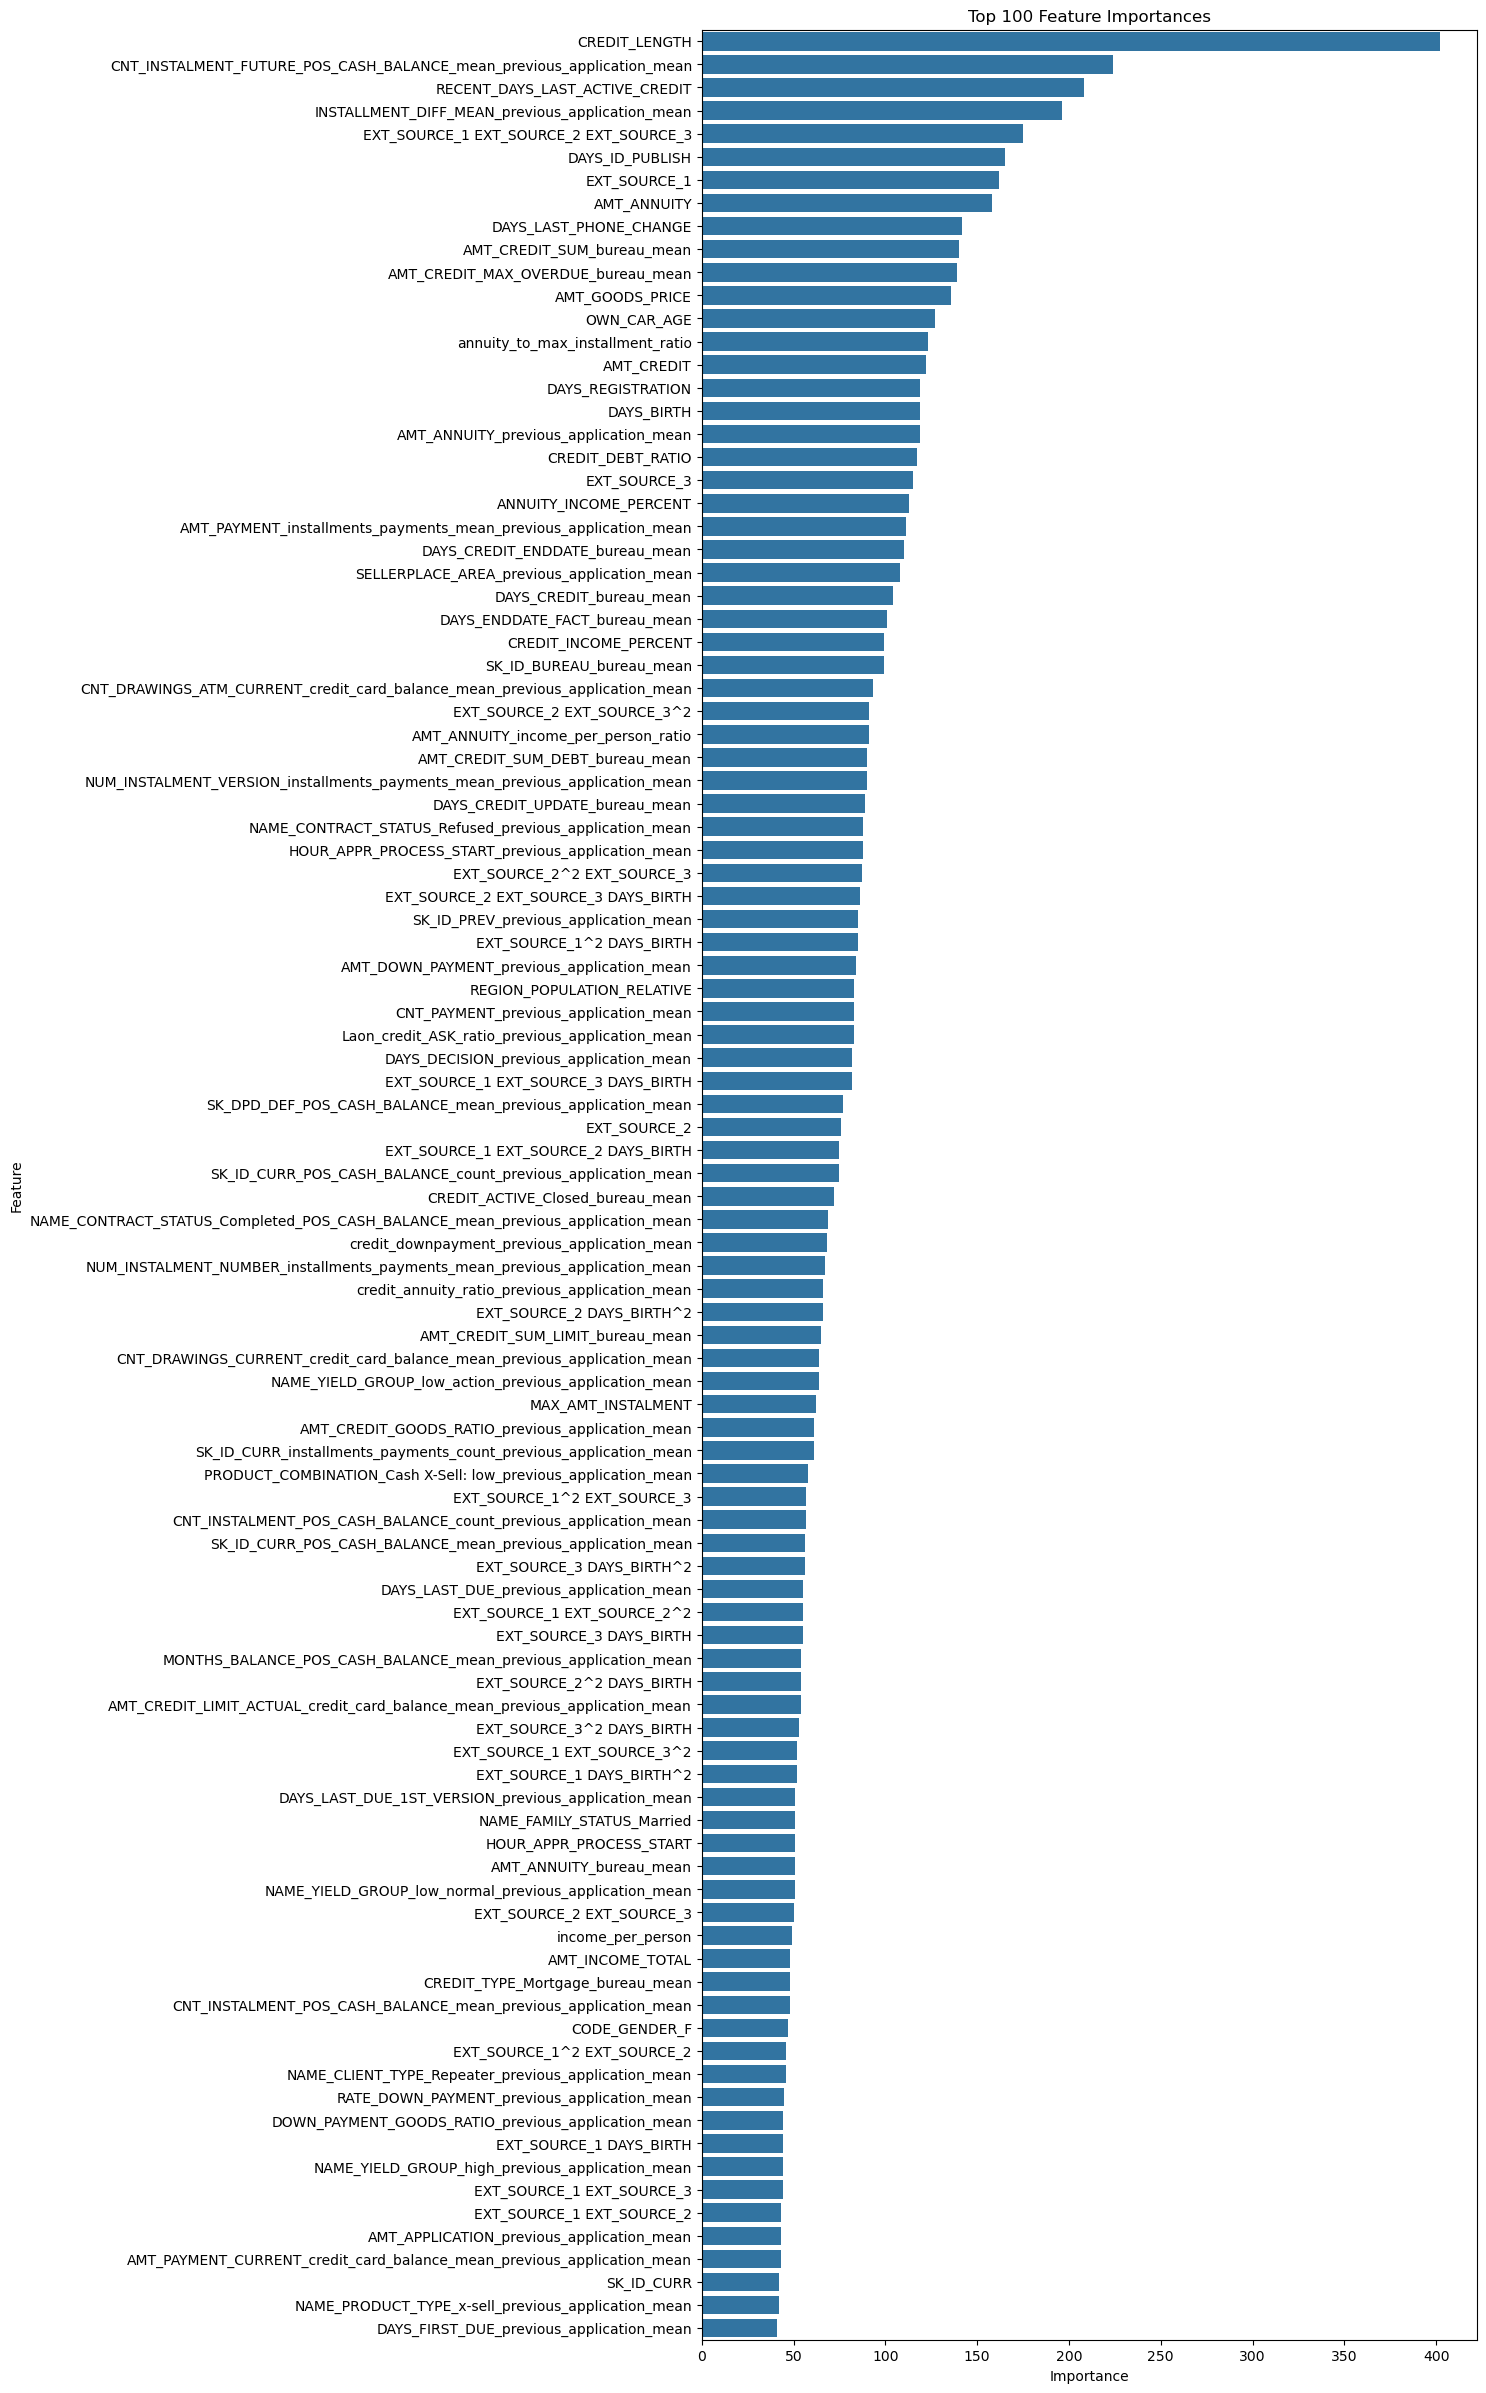

,Feature,Importance
105,CREDIT_LENGTH,402
238,CNT_INSTALMENT_FUTURE_POS_CASH_BALANCE_mean_pr...,224
143,RECENT_DAYS_LAST_ACTIVE_CREDIT,208
234,INSTALLMENT_DIFF_MEAN_previous_application_mean,196
128,EXT_SOURCE_1 EXT_SOURCE_2 EXT_SOURCE_3,175
...,...,...
218,AMT_APPLICATION_previous_application_mean,43
286,AMT_PAYMENT_CURRENT_credit_card_balance_mean_p...,43
0,SK_ID_CURR,42
426,NAME_PRODUCT_TYPE_x-sell_previous_application_...,42


In [34]:
#features.remove('TARGET')
feature_importances = model.feature_importances_
# Create a DataFrame for better visualization
feature_importances_df = pd.DataFrame({
    'Feature': features,
    'Importance': feature_importances
})

# Sort the DataFrame by importance
feature_importances_df = feature_importances_df.sort_values(by='Importance', ascending=False)

# Plot the feature importances
plt.figure(figsize=(10, 30))
sns.barplot(x='Importance', y='Feature', data=feature_importances_df.head(100))
plt.title('Top 100 Feature Importances')
plt.show()

# Display the DataFrame
feature_importances_df.head(100)

### RandomForestClassifier

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:   12.7s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   37.7s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.1s finished


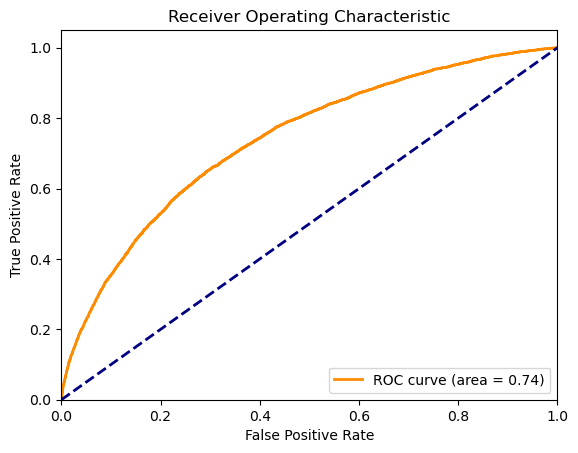

ROC AUC: 0.74


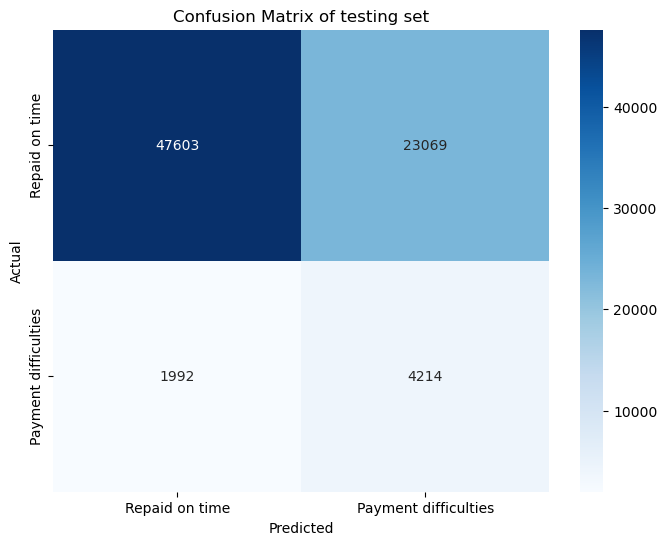

                      precision    recall  f1-score   support

      Repaid on time       0.96      0.67      0.79     70672
Payment difficulties       0.15      0.68      0.25      6206

            accuracy                           0.67     76878
           macro avg       0.56      0.68      0.52     76878
        weighted avg       0.89      0.67      0.75     76878



In [35]:
from sklearn.ensemble import RandomForestClassifier

# Make the random forest classifier
random_forest = RandomForestClassifier(n_estimators = 100, random_state = 50, verbose = 1, n_jobs = -1, class_weight='balanced',max_depth=5)
random_forest.fit(X_train, y_train)

# Extract feature importances
#feature_importance_values = random_forest.feature_importances_
#feature_importances = pd.DataFrame({'feature': features, 'importance': feature_importance_values})

y_pred = random_forest.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

print(f'ROC AUC: {roc_auc:.2f}')

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred.round())

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Repaid on time', 'Payment difficulties'], yticklabels=['Repaid on time', 'Payment difficulties'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix of testing set')
plt.show()

print(classification_report(y_test, y_pred.round(), target_names=['Repaid on time', 'Payment difficulties']))

### Kaggel submission

In [36]:
model = lgb.LGBMClassifier(n_estimators=450, objective='binary', 
                           class_weight='balanced', learning_rate=0.05, 
                           reg_alpha=0.1, reg_lambda=0.1, 
                           subsample=0.8, n_jobs=-1, random_state=50)
model.fit(train, y, eval_metric='auc')  

submission = model.predict_proba(test)[:, 1]
submit = application_test[['SK_ID_CURR']]
submit['TARGET'] = submission
submit.to_csv('lightgbm_2.csv', index = False)

[LightGBM] [Info] Number of positive: 24825, number of negative: 282686
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.345251 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 71532
[LightGBM] [Info] Number of data points in the train set: 307511, number of used features: 846
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


In [37]:
submission = random_forest.predict_proba(test)[:, 1]
submit = application_test[['SK_ID_CURR']]
submit['TARGET'] = submission
submit.to_csv('random_forest.csv', index = False)

[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished


### My best Kaggel score: 0.77076
### (kindly note that rank #1 scored 0.80570)